# Code-Capacity Performance On Half-Stabilizer Errors With Disordered Damping

This mirrors the half-stabilizer memory-performance notebook, but uses edge-wise damping instead of per-bit memory strengths. The two random families separate all-edge disorder from support-local disorder on the chosen half-stabilizer.


In [1]:
import importlib
from math import comb
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm


c:\Users\User\Documents\projects-git\relay_mother_folder\relay\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "relay_bp").exists():
            return candidate
    raise FileNotFoundError("Could not locate the relay repo root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from relay_bp.analysis.code_capacity_common import default_export_code_paths

CODE_PATHS = {
    "hgp_625": Path(r"C:\Users\User\Documents\projects-git\giulio\hgp_code_625_25_6_peg.npz"),
    "hgp_225": Path(r"C:\Users\User\Documents\cluster_decoder\cluster_decoder\codes\hgp_code_225.npz"),
    "surface5": Path(r"C:\Users\User\Documents\Code from BPGD\surface5_HxHzLxLz.npz"),
    "surface13": Path(r"C:\Users\User\Documents\Code from BPGD\surface13_HxHzLxLz.npz"),
    "B1": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\B1_HxHzLxLz.npz"),
    "gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\gross_HxHzLxLz.npz"),
    "two_gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\two_gross_HxHzLxLz.npz"),
}
selected_code = "gross"  # change here

npz_path = CODE_PATHS[selected_code]

prior_error_rate = 0.10
max_iter = 40
alpha = 1.0
same_damping_coefficient = 0.75
random_damping_interval = (0.50, 1.00)
base_disorder_seed = 0
random_coefficient_seed_offsets = [0, 1, 2]

DECODER_SPECS = {
    "bp": {
        "label": "Vanilla BP",
        "coeff_seed_offsets": [0],
    },
    "damp_same": {
        "label": "Damp-BP / same coefficient",
        "coeff_seed_offsets": [0],
    },
    "damp_random_all_edges": {
        "label": "Damp-BP / random interval on all edges",
        "coeff_seed_offsets": random_coefficient_seed_offsets,
    },
    "damp_random_support_only": {
        "label": "Damp-BP / random interval on stabilizer support",
        "coeff_seed_offsets": random_coefficient_seed_offsets,
    },
}


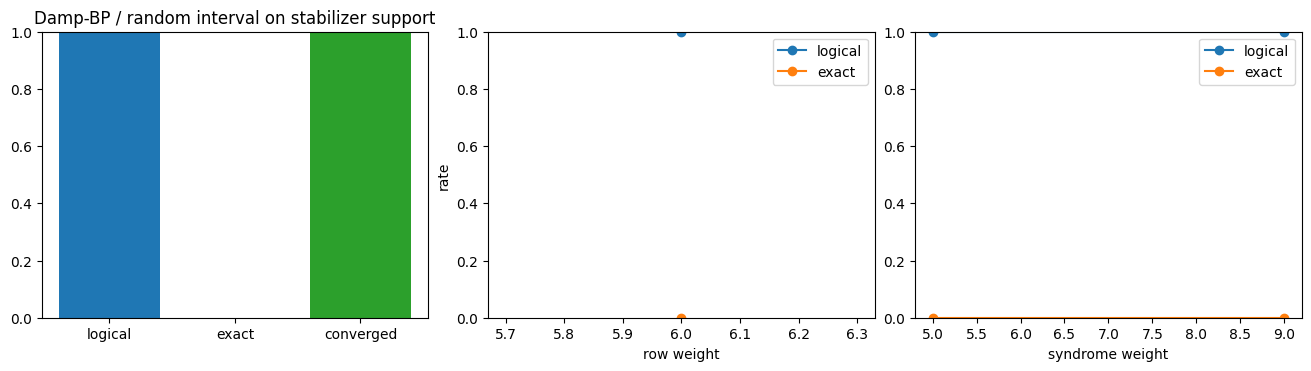

In [3]:
import importlib
from math import comb
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "relay_bp").exists():
            return candidate
    raise FileNotFoundError("Could not locate the relay repo root from the current working directory.")


REPO_ROOT = globals().get("REPO_ROOT", find_repo_root(Path.cwd()))
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import relay_bp.analysis.code_capacity_common as code_capacity_common_module

importlib.reload(code_capacity_common_module)

from relay_bp.analysis.code_capacity_common import (
    build_edge_damping_messages,
    default_export_code_paths,
    decode_with_edge_damping,
    decode_with_plain_bp,
    enumerate_half_stabilizer_cases,
    evaluate_decode_result,
    load_code_capacity_problem,
    make_min_sum_tracer,
)

CODE_PATHS = globals().get("CODE_PATHS", default_export_code_paths(REPO_ROOT))
selected_code = globals().get("selected_code", "surface13")
npz_path = globals().get("npz_path", CODE_PATHS[selected_code])
prior_error_rate = float(globals().get("prior_error_rate", 0.10))
max_iter = int(globals().get("max_iter", 40))
alpha = float(globals().get("alpha", 1.0))
same_damping_coefficient = float(globals().get("same_damping_coefficient", 0.75))
random_damping_interval = tuple(float(x) for x in globals().get("random_damping_interval", (0.50, 1.00)))
base_disorder_seed = int(globals().get("base_disorder_seed", 0))
random_coefficient_seed_offsets = list(globals().get("random_coefficient_seed_offsets", [0, 1, 2]))
DECODER_SPECS = globals().get(
    "DECODER_SPECS",
    {
        "bp": {"label": "Vanilla BP", "coeff_seed_offsets": [0]},
        "damp_same": {"label": "Damp-BP / same coefficient", "coeff_seed_offsets": [0]},
        "damp_random_all_edges": {
            "label": "Damp-BP / random interval on all edges",
            "coeff_seed_offsets": random_coefficient_seed_offsets,
        },
        "damp_random_support_only": {
            "label": "Damp-BP / random interval on stabilizer support",
            "coeff_seed_offsets": random_coefficient_seed_offsets,
        },
    },
)


def load_css_code(path: Path) -> dict[str, object]:
    problem = load_code_capacity_problem(path, default_prior_error_rate=prior_error_rate)
    return {
        "problem": problem,
        "hx": problem.hx,
        "hz": problem.hz,
        "lz": problem.lz,
        "metadata": problem.metadata,
    }


def stabilizer_statistics(hx: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]:
    weights = hx.sum(axis=1).astype(int)
    unique_weights, counts = np.unique(weights, return_counts=True)
    rows = []
    total_raw_half_subsets = 0
    total_even_weight_stabilizers = 0
    for weight, count in zip(unique_weights, counts):
        weight = int(weight)
        count = int(count)
        is_even = weight > 0 and weight % 2 == 0
        raw_half_subsets_per_row = comb(weight, weight // 2) if is_even else 0
        total_raw = count * raw_half_subsets_per_row
        if is_even:
            total_raw_half_subsets += total_raw
            total_even_weight_stabilizers += count
        rows.append(
            {
                "row_weight": weight,
                "n_x_stabilizers": count,
                "is_even_weight": is_even,
                "raw_half_subsets_per_row": raw_half_subsets_per_row,
                "total_raw_half_subsets": total_raw,
            }
        )
    summary = pd.DataFrame(
        [
            {
                "code": selected_code,
                "Hx_rows": int(hx.shape[0]),
                "n_qubits": int(hx.shape[1]),
                "even_weight_x_stabilizers": total_even_weight_stabilizers,
                "total_half_flip_patterns": total_raw_half_subsets,
            }
        ]
    )
    return pd.DataFrame(rows), summary


def case_manifest(cases: list[dict[str, object]], head: int | None = 20) -> pd.DataFrame:
    manifest = pd.DataFrame(
        [
            {
                "case_id": int(case["case_id"]),
                "row_idx": int(case["row_idx"]),
                "row_weight": int(case["row_weight"]),
                "half_subset_idx": int(case["half_subset_idx"]),
                "syndrome_weight": int(case["syndrome_weight"]),
                "support_bits": list(case["support_bits"]),
                "flipped_bits": list(case["flipped_bits"]),
            }
            for case in cases
        ]
    )
    return manifest.head(head) if head is not None else manifest


def build_damping_messages(decoder_kind: str, check_matrix, case: dict[str, object], coeff_seed: int):
    if decoder_kind == "bp":
        return None
    if decoder_kind == "damp_same":
        return build_edge_damping_messages(
            check_matrix,
            interval=(same_damping_coefficient, same_damping_coefficient),
            coeff_seed=0,
            support_bits=None,
        )
    if decoder_kind == "damp_random_all_edges":
        return build_edge_damping_messages(
            check_matrix,
            interval=random_damping_interval,
            coeff_seed=coeff_seed,
            support_bits=None,
        )
    if decoder_kind == "damp_random_support_only":
        return build_edge_damping_messages(
            check_matrix,
            interval=random_damping_interval,
            coeff_seed=coeff_seed,
            support_bits=tuple(int(bit) for bit in case["support_bits"]),
        )
    raise ValueError(f"Unsupported decoder kind: {decoder_kind}")


def evaluate_decoder(decoder_kind: str, cases: list[dict[str, object]], check_matrix, lz_matrix):
    del lz_matrix
    rows = []
    plain_tracer = make_min_sum_tracer(code_data["problem"], max_iter=max_iter, alpha=alpha, gamma0=None)
    damping_tracer = make_min_sum_tracer(code_data["problem"], max_iter=max_iter, alpha=alpha, gamma0=None)
    for case in cases:
        for coeff_seed_offset in DECODER_SPECS[decoder_kind]["coeff_seed_offsets"]:
            coeff_seed = int(base_disorder_seed) + (10_000 * int(coeff_seed_offset)) + int(case["case_id"])
            if decoder_kind == "bp":
                result = decode_with_plain_bp(plain_tracer, case["syndrome"], n_bits=code_data["problem"].n_bits)
                messages = None
            else:
                messages = build_damping_messages(decoder_kind, check_matrix, case, coeff_seed)
                result = decode_with_edge_damping(
                    damping_tracer,
                    case["syndrome"],
                    messages,
                    n_bits=code_data["problem"].n_bits,
                )
            evaluation = evaluate_decode_result(result=result, error=case["error"], lz=code_data["problem"].lz)
            rows.append(
                {
                    "decoder_kind": decoder_kind,
                    "label": DECODER_SPECS[decoder_kind]["label"],
                    "case_id": int(case["case_id"]),
                    "row_idx": int(case["row_idx"]),
                    "row_weight": int(case["row_weight"]),
                    "half_subset_idx": int(case["half_subset_idx"]),
                    "syndrome_weight": int(case["syndrome_weight"]),
                    "coeff_seed_offset": int(coeff_seed_offset),
                    "coeff_seed": int(coeff_seed),
                    "converged": bool(result.success),
                    "logical_success": bool(evaluation.logical_success),
                    "exact_recovery": bool(evaluation.exact_recovery),
                    "logical_weight": int(evaluation.logical_weight),
                    "iterations": int(result.iterations),
                    "damping_min": np.nan if messages is None else float(np.min(messages)),
                    "damping_max": np.nan if messages is None else float(np.max(messages)),
                    "nontrivial_edges": 0 if messages is None else int(np.sum(np.abs(np.asarray(messages) - 1.0) > 1e-12)),
                }
            )
    rows_df = pd.DataFrame(rows)
    summary_df = pd.DataFrame(
        [
            {
                "decoder_kind": decoder_kind,
                "label": DECODER_SPECS[decoder_kind]["label"],
                "n_trials": int(len(rows_df)),
                "logical_success_rate": float(rows_df["logical_success"].mean()),
                "exact_recovery_rate": float(rows_df["exact_recovery"].mean()),
                "convergence_rate": float(rows_df["converged"].mean()),
                "mean_iterations": float(rows_df["iterations"].mean()),
                "mean_logical_weight": float(rows_df["logical_weight"].mean()),
            }
        ]
    )
    by_row_weight = (
        rows_df.groupby("row_weight", as_index=False)
        .agg(
            n_trials=("case_id", "size"),
            logical_success_rate=("logical_success", "mean"),
            exact_recovery_rate=("exact_recovery", "mean"),
            convergence_rate=("converged", "mean"),
            mean_iterations=("iterations", "mean"),
        )
        .sort_values("row_weight")
    )
    by_syndrome_weight = (
        rows_df.groupby("syndrome_weight", as_index=False)
        .agg(
            n_trials=("case_id", "size"),
            logical_success_rate=("logical_success", "mean"),
            exact_recovery_rate=("exact_recovery", "mean"),
            convergence_rate=("converged", "mean"),
        )
        .sort_values("syndrome_weight")
    )
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), constrained_layout=True)
    axes[0].bar(
        ["logical", "exact", "converged"],
        [
            float(summary_df.iloc[0]["logical_success_rate"]),
            float(summary_df.iloc[0]["exact_recovery_rate"]),
            float(summary_df.iloc[0]["convergence_rate"]),
        ],
        color=["tab:blue", "tab:orange", "tab:green"],
    )
    axes[0].set_ylim(0.0, 1.0)
    axes[0].set_title(DECODER_SPECS[decoder_kind]["label"])
    axes[1].plot(by_row_weight["row_weight"], by_row_weight["logical_success_rate"], marker="o", label="logical")
    axes[1].plot(by_row_weight["row_weight"], by_row_weight["exact_recovery_rate"], marker="o", label="exact")
    axes[1].set_xlabel("row weight")
    axes[1].set_ylabel("rate")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].legend(loc="best")
    axes[2].plot(by_syndrome_weight["syndrome_weight"], by_syndrome_weight["logical_success_rate"], marker="o", label="logical")
    axes[2].plot(by_syndrome_weight["syndrome_weight"], by_syndrome_weight["exact_recovery_rate"], marker="o", label="exact")
    axes[2].set_xlabel("syndrome weight")
    axes[2].set_ylim(0.0, 1.0)
    axes[2].legend(loc="best")
    return {
        "rows": rows_df,
        "summary": summary_df,
        "by_row_weight": by_row_weight,
        "by_syndrome_weight": by_syndrome_weight,
        "figure": fig,
    }


def exact_vs_logical_ranking(results_map: dict[str, dict[str, object]]) -> pd.DataFrame:
    rows = []
    for name, payload in results_map.items():
        summary = payload["summary"].iloc[0]
        rows.append(
            {
                "decoder_kind": name,
                "label": str(summary["label"]),
                "logical_success_rate": float(summary["logical_success_rate"]),
                "exact_recovery_rate": float(summary["exact_recovery_rate"]),
                "convergence_rate": float(summary["convergence_rate"]),
                "logical_rank": 0,
                "exact_rank": 0,
            }
        )
    ranking = pd.DataFrame(rows)
    ranking["logical_rank"] = ranking["logical_success_rate"].rank(method="dense", ascending=False).astype(int)
    ranking["exact_rank"] = ranking["exact_recovery_rate"].rank(method="dense", ascending=False).astype(int)
    return ranking.sort_values(["logical_rank", "exact_rank", "decoder_kind"]).reset_index(drop=True)


code_data = load_css_code(npz_path)
hz_check_matrix = code_data["hz"]
lz_matrix = code_data["lz"]
stabilizer_rows, stabilizer_summary = stabilizer_statistics(code_data["hx"])
all_cases = enumerate_half_stabilizer_cases(code_data["problem"])
case_manifest_df = case_manifest(all_cases)


_smoke_cases = all_cases[:4]
_smoke_results = evaluate_decoder("damp_random_support_only", _smoke_cases, hz_check_matrix, lz_matrix)
assert int(_smoke_results["summary"].iloc[0]["n_trials"]) == len(_smoke_cases) * len(random_coefficient_seed_offsets)
assert "logical_success_rate" in _smoke_results["summary"].columns


## Half-Stabilizer Error Set Statistics


In [4]:
display(stabilizer_summary)
display(stabilizer_rows)
display(case_manifest_df)


,code,Hx_rows,n_qubits,even_weight_x_stabilizers,total_half_flip_patterns
0,gross,72,144,72,1440


,row_weight,n_x_stabilizers,is_even_weight,raw_half_subsets_per_row,total_raw_half_subsets
0,6,72,True,20,1440


,case_id,row_idx,row_weight,half_subset_idx,syndrome_weight,support_bits,flipped_bits
0,0,0,6,0,9,"[1, 2, 18, 75, 78, 84]","[1, 2, 18]"
1,1,0,6,1,5,"[1, 2, 18, 75, 78, 84]","[1, 2, 75]"
2,2,0,6,2,5,"[1, 2, 18, 75, 78, 84]","[1, 2, 78]"
3,3,0,6,3,5,"[1, 2, 18, 75, 78, 84]","[1, 2, 84]"
4,4,0,6,4,5,"[1, 2, 18, 75, 78, 84]","[1, 18, 75]"
5,5,0,6,5,5,"[1, 2, 18, 75, 78, 84]","[1, 18, 78]"
6,6,0,6,6,5,"[1, 2, 18, 75, 78, 84]","[1, 18, 84]"
7,7,0,6,7,5,"[1, 2, 18, 75, 78, 84]","[1, 75, 78]"
8,8,0,6,8,5,"[1, 2, 18, 75, 78, 84]","[1, 75, 84]"
9,9,0,6,9,5,"[1, 2, 18, 75, 78, 84]","[1, 78, 84]"


## Decoder Cells


,decoder_kind,label,n_trials,logical_success_rate,exact_recovery_rate,convergence_rate,mean_iterations,mean_logical_weight
0,bp,Vanilla BP,1440,0.0,0.0,0.0,40.0,5.652778


,row_weight,n_trials,logical_success_rate,exact_recovery_rate,convergence_rate,mean_iterations
0,6,1440,0.0,0.0,0.0,40.0


,syndrome_weight,n_trials,logical_success_rate,exact_recovery_rate,convergence_rate
0,5,1296,0.0,0.0,0.0
1,9,144,0.0,0.0,0.0


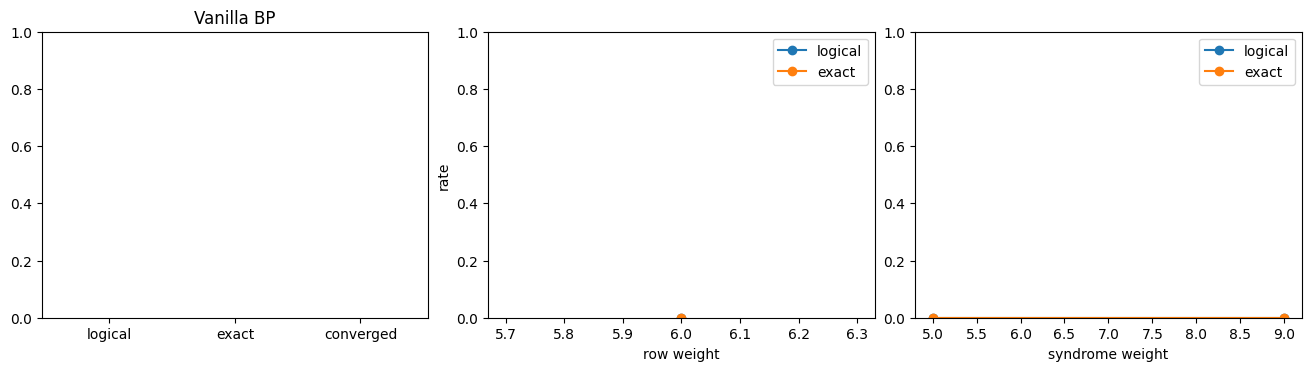

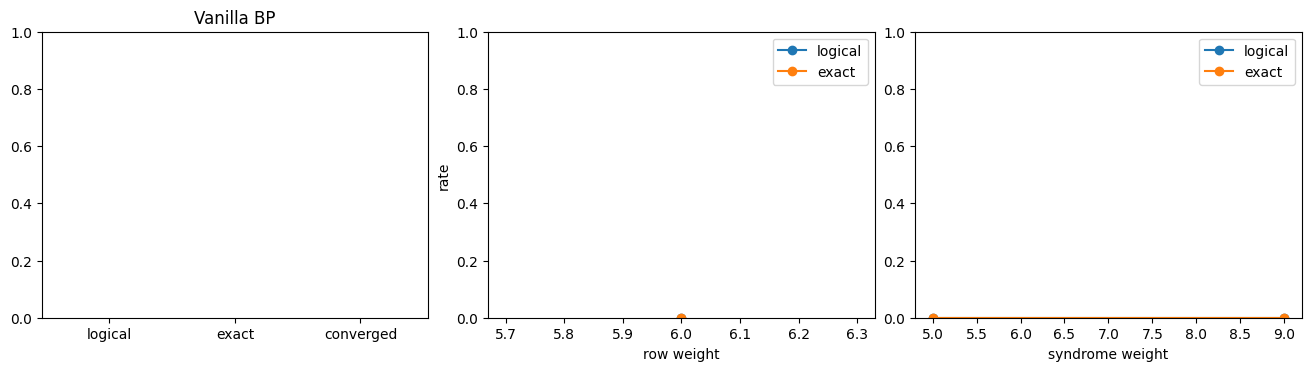

In [5]:
results_bp = evaluate_decoder("bp", all_cases, hz_check_matrix, lz_matrix)
display(results_bp["summary"])
display(results_bp["by_row_weight"])
display(results_bp["by_syndrome_weight"])
results_bp["figure"]


,decoder_kind,label,n_trials,logical_success_rate,exact_recovery_rate,convergence_rate,mean_iterations,mean_logical_weight
0,damp_same,Damp-BP / same coefficient,1440,0.806944,0.3,0.6,31.225,0.619444


,row_weight,n_trials,logical_success_rate,exact_recovery_rate,convergence_rate,mean_iterations
0,6,1440,0.806944,0.3,0.6,31.225


,syndrome_weight,n_trials,logical_success_rate,exact_recovery_rate,convergence_rate
0,5,1296,0.822531,0.333333,0.666667
1,9,144,0.666667,0.000000,0.000000


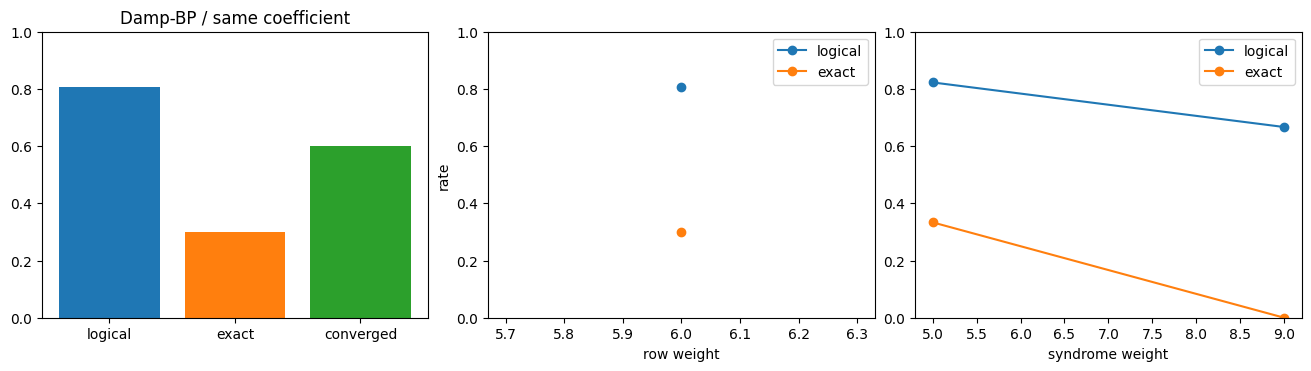

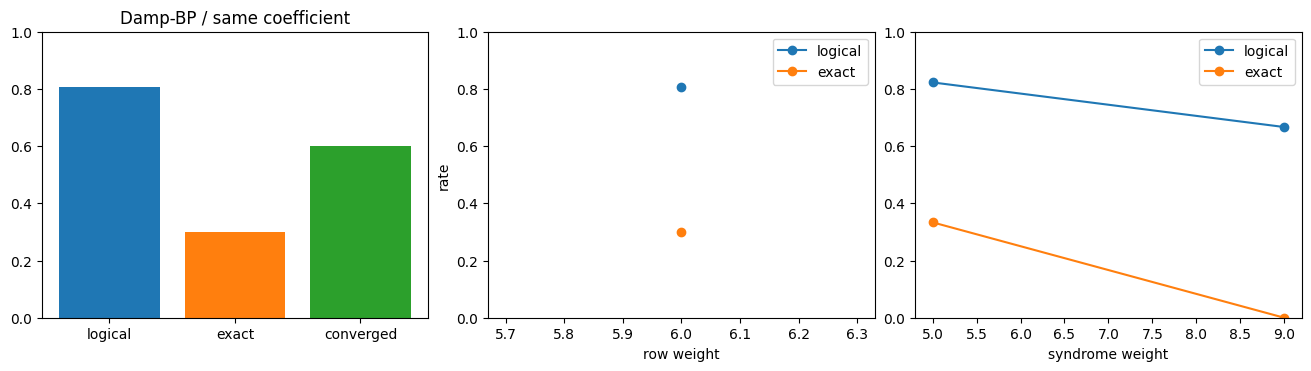

In [6]:
results_damp_same = evaluate_decoder("damp_same", all_cases, hz_check_matrix, lz_matrix)
display(results_damp_same["summary"])
display(results_damp_same["by_row_weight"])
display(results_damp_same["by_syndrome_weight"])
results_damp_same["figure"]


,decoder_kind,label,n_trials,logical_success_rate,exact_recovery_rate,convergence_rate,mean_iterations,mean_logical_weight
0,damp_random_all_edges,Damp-BP / random interval on all edges,4320,1.0,0.511111,1.0,3.427315,0.0


,row_weight,n_trials,logical_success_rate,exact_recovery_rate,convergence_rate,mean_iterations
0,6,4320,1.0,0.511111,1.0,3.427315


,syndrome_weight,n_trials,logical_success_rate,exact_recovery_rate,convergence_rate
0,5,3888,1.0,0.510031,1.0
1,9,432,1.0,0.520833,1.0


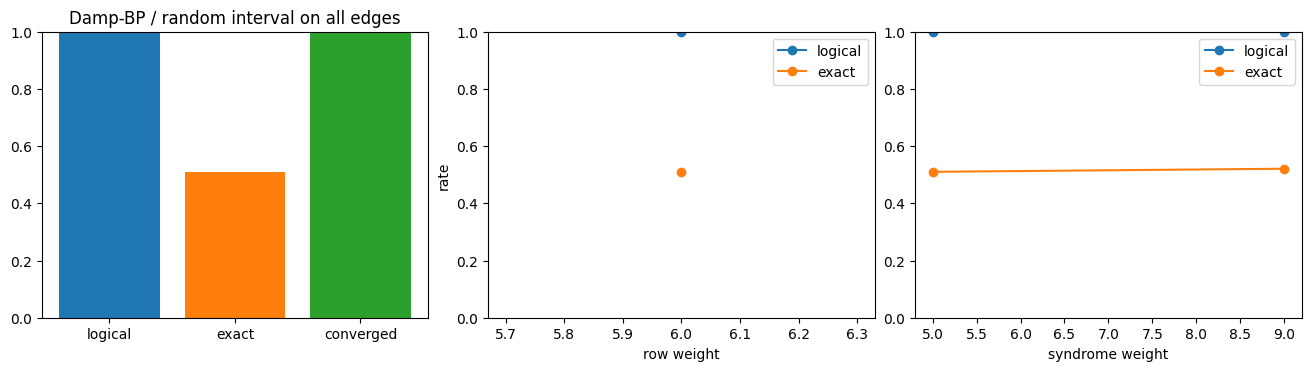

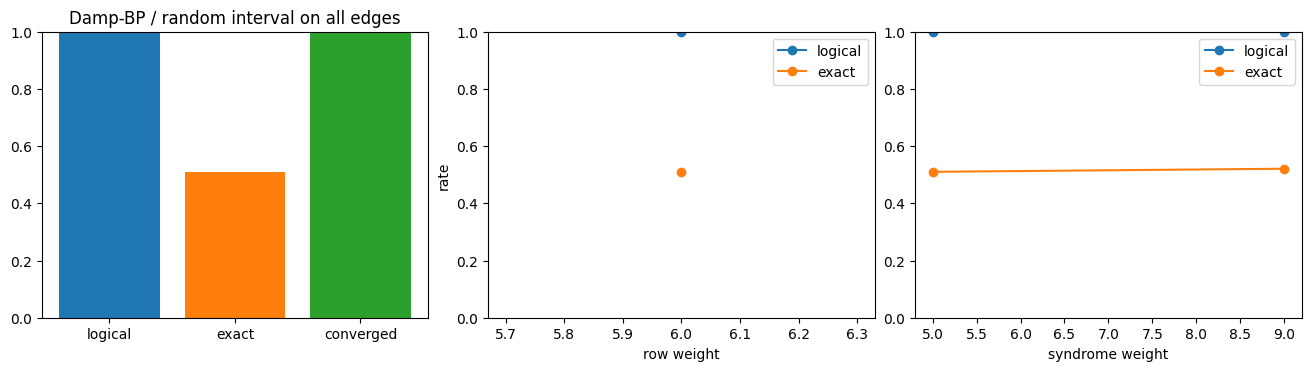

In [7]:
results_damp_random_all_edges = evaluate_decoder("damp_random_all_edges", all_cases, hz_check_matrix, lz_matrix)
display(results_damp_random_all_edges["summary"])
display(results_damp_random_all_edges["by_row_weight"])
display(results_damp_random_all_edges["by_syndrome_weight"])
results_damp_random_all_edges["figure"]


,decoder_kind,label,n_trials,logical_success_rate,exact_recovery_rate,convergence_rate,mean_iterations,mean_logical_weight
0,damp_random_support_only,Damp-BP / random interval on stabilizer support,4320,0.999074,0.496759,0.999074,3.824537,0.003009


,row_weight,n_trials,logical_success_rate,exact_recovery_rate,convergence_rate,mean_iterations
0,6,4320,0.999074,0.496759,0.999074,3.824537


,syndrome_weight,n_trials,logical_success_rate,exact_recovery_rate,convergence_rate
0,5,3888,0.998971,0.497171,0.998971
1,9,432,1.000000,0.493056,1.000000


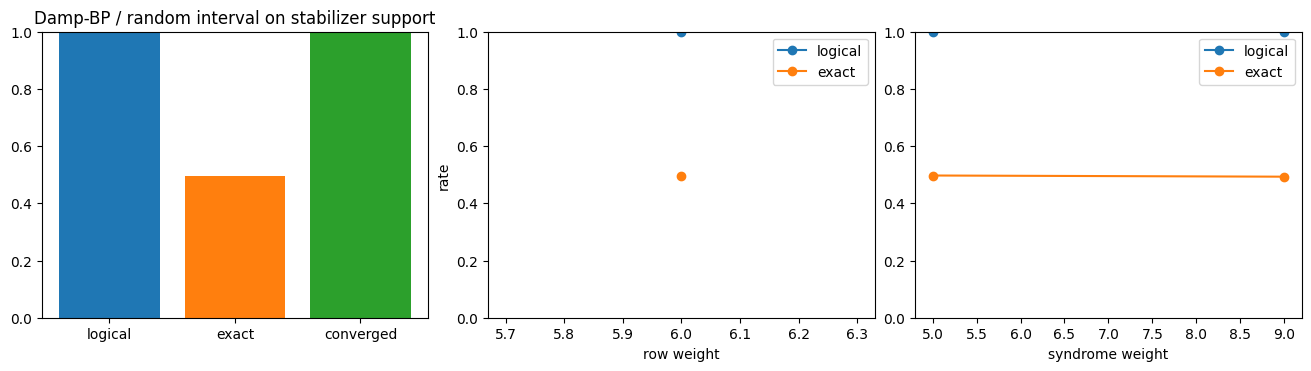

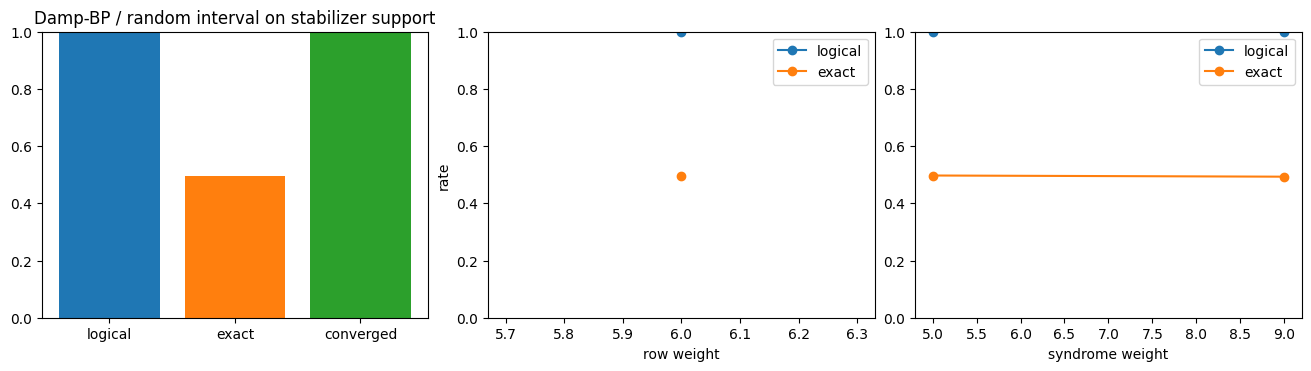

In [8]:
results_damp_random_support_only = evaluate_decoder("damp_random_support_only", all_cases, hz_check_matrix, lz_matrix)
display(results_damp_random_support_only["summary"])
display(results_damp_random_support_only["by_row_weight"])
display(results_damp_random_support_only["by_syndrome_weight"])
results_damp_random_support_only["figure"]


## Optional Extension

A useful end-of-notebook cross-check is to rank decoder families once by logical success and once by exact recovery. For half-stabilizer cases, that quickly shows whether a family is genuinely better or is only choosing a different representative of the same logical class.


In [9]:
ranking_df = exact_vs_logical_ranking(
    {
        "bp": results_bp,
        "damp_same": results_damp_same,
        "damp_random_all_edges": results_damp_random_all_edges,
        "damp_random_support_only": results_damp_random_support_only,
    }
)
display(ranking_df)


,decoder_kind,label,logical_success_rate,exact_recovery_rate,convergence_rate,logical_rank,exact_rank
0,damp_random_all_edges,Damp-BP / random interval on all edges,1.000000,0.511111,1.000000,1,1
1,damp_random_support_only,Damp-BP / random interval on stabilizer support,0.999074,0.496759,0.999074,2,2
2,damp_same,Damp-BP / same coefficient,0.806944,0.300000,0.600000,3,3
3,bp,Vanilla BP,0.000000,0.000000,0.000000,4,4
